<a href="https://colab.research.google.com/github/Akhilon-MKS/24BAD008-DL-Lab/blob/main/24BAD008_DL_Ex_No_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN for Text Generation using Tiny Shakespeare

## 1. Install required library

In [1]:
print("Akhilon S - 24BAD008")
!pip install -q datasets
!pip install -q tensorflow


Akhilon S - 24BAD008
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 770.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 151.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 80.5 MB/s eta 0:00:00


## 2. Import libraries

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## 4. Set random seed
Ensures reproducibility.

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

## Part A: Dataset Preparation

### 5. Load Tiny Shakespeare dataset

In [4]:
dataset = load_dataset("Trelis/tiny-shakespeare")
print(dataset)

README.md:   0%|          | 0.00/497 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/119k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/472 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})


### 6. Explore the dataset

In [5]:
print(dataset["train"])
print(dataset["test"])
print(dataset["train"][0])

Dataset({
    features: ['Text'],
    num_rows: 472
})
Dataset({
    features: ['Text'],
    num_rows: 49
})
{'Text': "First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance 

### 7. Extract all Shakespeare text
Column name is `Text` (capital T); combine all training examples.

In [6]:
text = "\n".join(example["Text"] for example in dataset["train"])
print("Total number of characters:", len(text))
print(text[:1000])

Total number of characters: 1222825
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for

### 8. Convert text to lowercase
So that King / king / KING are treated as the same word.

In [7]:
text = text.lower()
print(text[:500])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


### 9. Tokenization

In [8]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts([text])
tokens = tokenizer.texts_to_sequences([text])[0]
print(tokens[:30])

[80, 261, 150, 35, 876, 149, 651, 128, 16, 107, 36, 107, 107, 80, 261, 8, 42, 36, 1383, 348, 4, 193, 66, 4, 4237, 36, 1383, 1383, 80, 261]


### 10. Create vocabulary

In [9]:
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for reserved index 0
print("Vocabulary size:", vocab_size)

for word, index in list(word_index.items())[:20]:
    print(index, "->", word)

Vocabulary size: 11981
1 -> <OOV>
2 -> the
3 -> and
4 -> to
5 -> i
6 -> of
7 -> my
8 -> you
9 -> a
10 -> that
11 -> in
12 -> is
13 -> not
14 -> for
15 -> with
16 -> me
17 -> it
18 -> your
19 -> be
20 -> his


### 11. Define sequence length
Model uses the previous 20 words to predict the next word.

In [10]:
SEQ_LENGTH = 20

### 12. Create input sequences

In [11]:
sequences = []
for i in range(SEQ_LENGTH, len(tokens)):
    sequences.append(tokens[i - SEQ_LENGTH : i + 1])

sequences = np.array(sequences)
print("Number of sequences:", len(sequences))
print("Sequence shape:", sequences.shape)

Number of sequences: 223866
Sequence shape: (223866, 21)


### 13. Separate input X and target y

In [12]:
X = sequences[:, :-1]
y = sequences[:, -1]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (223866, 20)
y shape: (223866,)


### 14. Display an example sequence

In [13]:
reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

input_words = [reverse_word_index.get(token, "<UNKNOWN>") for token in X[0]]
target_word = reverse_word_index.get(y[0], "<UNKNOWN>")

print("Input words:", " ".join(input_words))
print("Target next word:", target_word)

Input words: first citizen before we proceed any further hear me speak all speak speak first citizen you are all resolved rather
Target next word: to


### 15. Training and validation split
80% train, 20% validation.

In [14]:
split_index = int(0.8 * len(X))

X_train, y_train = X[:split_index], y[:split_index]
X_val, y_val = X[split_index:], y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 179092
Validation samples: 44774


## Part B: Implementing the RNN Model

### 16. Define model parameters

In [15]:
EMBEDDING_DIM = 128
RNN_UNITS = 128

print("Vocabulary size :", vocab_size)
print("Sequence length :", SEQ_LENGTH)
print("Embedding size  :", EMBEDDING_DIM)
print("RNN units       :", RNN_UNITS)

Vocabulary size : 11981
Sequence length : 20
Embedding size  : 128
RNN units       : 128


### 17. Create RNN model
Embedding -> SimpleRNN -> Dense (softmax) to predict the next word.

In [16]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
    SimpleRNN(RNN_UNITS),
    Dense(vocab_size, activation="softmax")
])

### 18. Display model summary

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 19. Compile the model

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Part C: Train the RNN Model

### 20. Training parameters

In [19]:
EPOCHS = 50
BATCH_SIZE = 128

### 21. Train the model

In [20]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.0472 - loss: 6.6987 - val_accuracy: 0.0688 - val_loss: 6.7164
Epoch 2/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.0875 - loss: 5.9748 - val_accuracy: 0.0827 - val_loss: 6.7270
Epoch 3/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 73s 52ms/step - accuracy: 0.1060 - loss: 5.5664 - val_accuracy: 0.0830 - val_loss: 6.8160
Epoch 4/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.1233 - loss: 5.2200 - val_accuracy: 0.0797 - val_loss: 6.9573
Epoch 5/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.1456 - loss: 4.9039 - val_accuracy: 0.0757 - val_loss: 7.1183
Epoch 6/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.1729 - loss: 4.6120 - val_accuracy: 0.0725 - val_loss: 7.2904
Epoch 7/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.2037 - loss: 4.3471 - val_accuracy: 0.0710 - val_loss: 7.4648
Epoch 8/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.2343 -

### 22. Evaluate model

In [21]:
val_loss, val_accuracy = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=1)

print("Validation Loss     :", val_loss)
print("Validation Accuracy :", val_accuracy)

350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.0439 - loss: 10.6466
Validation Loss     : 10.646627426147461
Validation Accuracy : 0.04388707876205444


### 23. Display final training metrics

In [22]:
final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print("Training Accuracy   :", final_train_accuracy)
print("Validation Accuracy :", final_val_accuracy)
print("Training Loss       :", final_train_loss)
print("Validation Loss     :", final_val_loss)

Training Accuracy   : 0.5784568786621094
Validation Accuracy : 0.04388707876205444
Training Loss       : 1.9422093629837036
Validation Loss     : 10.646627426147461


### 24. Plot accuracy vs epoch

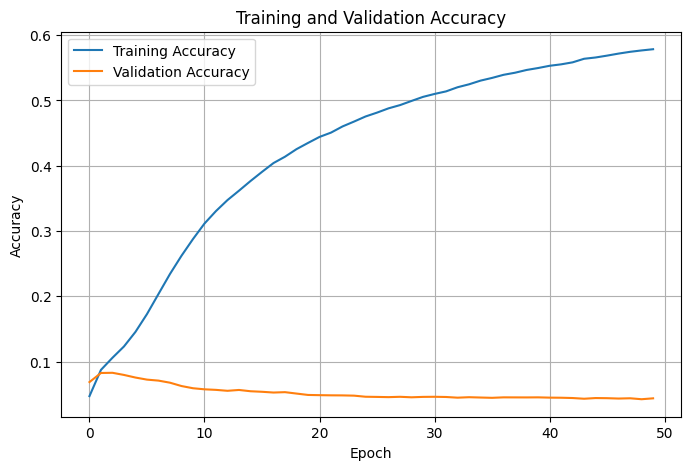

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### 25. Plot loss vs epoch

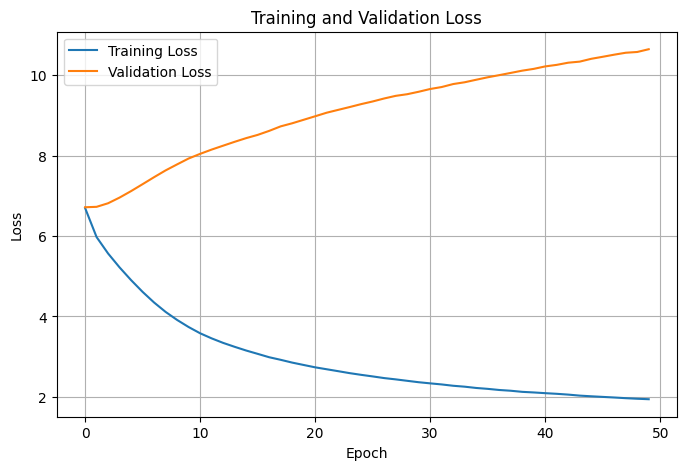

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## Part D: Text Generation

### 26. Next-word prediction function

In [25]:
def predict_next_word(seed_text):
    seed_text = seed_text.lower()
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = token_list[-SEQ_LENGTH:]

    # Pad if the seed has fewer than SEQ_LENGTH words
    if len(token_list) < SEQ_LENGTH:
        token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding="pre")[0]

    token_list = np.array(token_list).reshape(1, SEQ_LENGTH)

    predictions = model.predict(token_list, verbose=0)
    predicted_id = np.argmax(predictions[0])

    for word, index in tokenizer.word_index.items():
        if index == predicted_id:
            return word
    return ""

### 27. Test next-word prediction

In [26]:
seed = "the king"
next_word = predict_next_word(seed)

print("Seed text           :", seed)
print("Predicted next word :", next_word)

Seed text           : the king
Predicted next word : is


### 28. Text generation function

In [27]:
def generate_text(seed_text, num_words=30):
    generated_text = seed_text
    for _ in range(num_words):
        next_word = predict_next_word(generated_text)
        if next_word == "":
            break
        generated_text += " " + next_word
    return generated_text

### 29. Generate text — Sample 1

In [28]:
seed_text_1 = "the king"
generated_1 = generate_text(seed_text_1, num_words=30)

print("Seed:", seed_text_1)
print("Generated Text:", generated_1)

Seed: the king
Generated Text: the king is thy bed the duke of norfolk thomas mowbray a wrong prince how fares my gracious lord the king is slain if thou hast worn out thy fatal prison fall


### 30. Generate text — Sample 2

In [29]:
seed_text_2 = "my lord"
generated_2 = generate_text(seed_text_2, num_words=30)

print("Seed:", seed_text_2)
print("Generated Text:", generated_2)

Seed: my lord
Generated Text: my lord is my lord of gloucester his noble lords have i the extreme heir of this sweet general will mamillius it is it in your good my lord is that the


### 31. Generate text — Sample 3

In [30]:
seed_text_3 = "i will"
generated_3 = generate_text(seed_text_3, num_words=30)

print("Seed:", seed_text_3)
print("Generated Text:", generated_3)

Seed: i will
Generated Text: i will my son tush that lies the time to answer him to thee juliet what then a little kindred of this feast but who even so he was lost for one


### 32. Compare generated text

In [31]:
print("[ SAMPLE 1 ] Seed: the king")
print(generated_1)

print("\n[ SAMPLE 2 ] Seed: my lord")
print(generated_2)

print("\n[ SAMPLE 3 ] Seed: i will")
print(generated_3)

[ SAMPLE 1 ] Seed: the king
the king is thy bed the duke of norfolk thomas mowbray a wrong prince how fares my gracious lord the king is slain if thou hast worn out thy fatal prison fall

[ SAMPLE 2 ] Seed: my lord
my lord is my lord of gloucester his noble lords have i the extreme heir of this sweet general will mamillius it is it in your good my lord is that the

[ SAMPLE 3 ] Seed: i will
i will my son tush that lies the time to answer him to thee juliet what then a little kindred of this feast but who even so he was lost for one


### 33. Observation

The RNN was trained on the Tiny Shakespeare dataset using an Embedding layer, a SimpleRNN
layer, and a Dense softmax output layer to predict the next word given the previous 20 words.
It was trained with the Adam optimizer and sparse categorical crossentropy loss, and training/
validation accuracy and loss were tracked and plotted.

The trained model was used to generate text by repeatedly predicting the next word from seed
sentences. Some repetition or incoherence is expected, since SimpleRNNs struggle with
long-term dependencies.

### 34. Save trained model

In [32]:
model.save("rnn_text_generation_model.keras")
print("Trained model saved as: rnn_text_generation_model.keras")

Trained model saved as: rnn_text_generation_model.keras
